# Load Dataset
Download the CIFAR-10 dataset.

In [5]:
# Import dataset and dataset-to-tensor module
import torchvision
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [6]:
# Data loading and transformations
transform = transforms.Compose([
  transforms.RandomHorizontalFlip(),
  transforms.RandomCrop(32, padding=4),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [7]:
# Use PyTorch's torchvision.transforms.ToTenesor() to convert the dataset to tensor format
train_set = CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170498071/170498071 [10:27<00:00, 271875.31it/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [8]:
# Use PyTorch's DataLoader to divide the dataset into mini-batches and load the data
train_loader = DataLoader(dataset=train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=64, shuffle=False)

In [9]:
# Let's check the shape of train, test dataset
train_images, train_labels = next(iter(train_loader))
test_images, test_labels = next(iter(test_loader))

print("Shape of train_images:", train_images.shape)
print("Shape of train_labels:", train_labels.shape)
print("Shape of test_images:", test_images.shape)
print("Shape of test_labels:", test_labels.shape)

Shape of train_images: torch.Size([64, 3, 32, 32])
Shape of train_labels: torch.Size([64])
Shape of test_images: torch.Size([64, 3, 32, 32])
Shape of test_labels: torch.Size([64])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

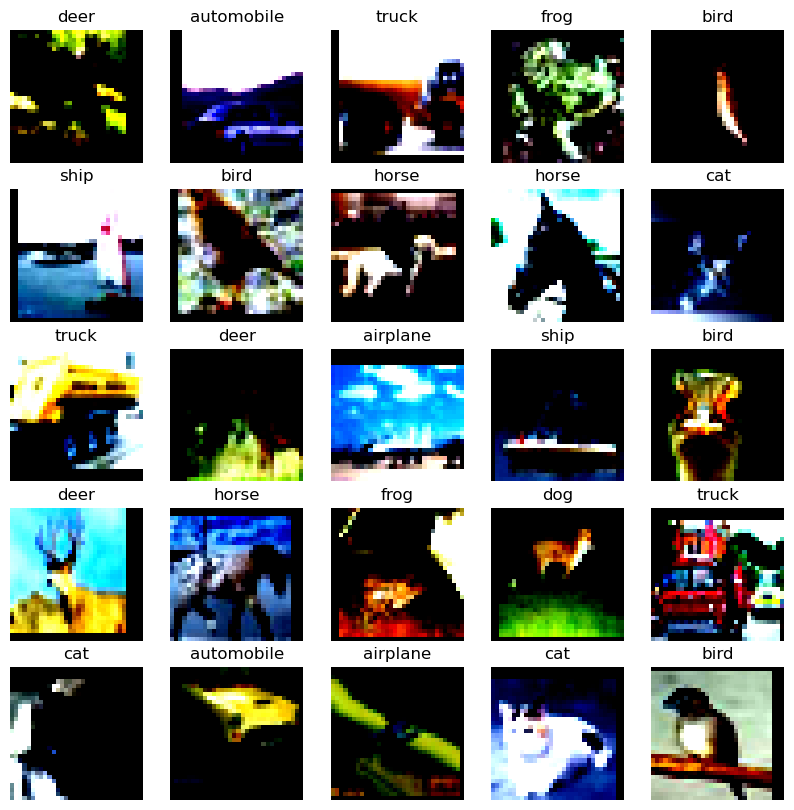

In [10]:
# Visualization of train dataset samples
import matplotlib.pyplot as plt

classes = train_set.classes

batch = next(iter(train_loader))
images, labels = batch

grid_img = torchvision.utils.make_grid(images[:25], nrow=5, padding=5)

# Display titles below each image
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))  # Permute dimensions for matplotlib (C, H, W) -> (H, W, C)
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

In order to train models with more layers than CNN, we need to use GPU(CUDA) because CPU requires a lot of time.

In [11]:
import torch
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


Now let's check output shape and the number of parameters of layers

# ResNet
ResNet has achieved very high performance in image recognition and classification tasks, and has been a significant contributor to maximizing the depth of deep learning networks. The key idea is to enable learning even in very deep neural networks through residual learning.



![](https://i.imgur.com/71IzITM.png)

The output of the residual block is expressed in the form of the output of the previous layer plus the input.

$$\large y = F(x, {w_i} + x) $$

$x$: Input of the block <br>
$F(x, {w_i})$: Residual function <br>
$y$: Output of the block

![](https://i.imgur.com/qYvphxR.png)


ResNet18 architecture

# Q. Implement forward pass in ResNet (3 points)

In [12]:
import torch
import torch.nn as nn

class ResNetBlock(nn.Module):
    '''
    It contains two 3x3 convolutional layers along with batch normalization and ReLU activations.
    This block uses residual connections to add the input (shortcut) to the output of the convolutional layers.
    '''
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResNetBlock, self).__init__()
        self.residual_function = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )

        # Shortcut for matching dimensions when stride != 1 or channel sizes differ
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # Compute the residual function
        residual = self.residual_function(x)
        # Compute the shortcut connection
        shortcut = self.shortcut(x)
        # Add the shortcut to the residual and apply ReLU
        out = torch.relu(residual + shortcut)
        return out

class ResNet(nn.Module):
    '''
    Defines the full ResNet-18 model.
    '''
    def __init__(self, block, layers, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64
        # Initial convolution layer
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        # Create residual layers
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        # Global average pooling and a fully connected layer
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        layers = []
        # First block may change dimensions (via stride or channel numbers)
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        # Remaining blocks keep the same dimensions
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Pass input through the initial convolution layer
        x = self.conv1(x)
        # Pass through each residual layer
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # Apply global average pooling
        x = self.avg_pool(x)
        # Flatten the output tensor
        x = x.view(x.size(0), -1)
        # Fully connected layer for classification
        x = self.fc(x)
        return x

def ResNet18():
    return ResNet(ResNetBlock, [2, 2, 2, 2])

In [13]:
model_res = ResNet18().to(device)

Check information of the model with summary function of the torchsummary.


In [3]:

import torch
import torch.nn as nn

class ResNetBlock(nn.Module):
    '''
    두 개의 3x3 convolutional layer와 Batch Normalization, ReLU activation을 포함하는 block입니다.
    residual connection을 통해 입력과 출력이 더해집니다.
    '''
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResNetBlock, self).__init__()
        self.residual_function = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        residual = self.residual_function(x)
        shortcut = self.shortcut(x)
        out = torch.relu(residual + shortcut)
        return out

class ResNet(nn.Module):
    '''
    ResNet-18 전체 모델 정의
    '''
    def __init__(self, block, layers, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
    
    def _make_layer(self, block, out_channels, blocks, stride=1):
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv1(x)         # 초기 Convolution
        x = self.layer1(x)        # 1번째 ResNet Block Layer
        x = self.layer2(x)        # 2번째 ResNet Block Layer (downsample)
        x = self.layer3(x)        # 3번째 ResNet Block Layer (downsample)
        x = self.layer4(x)        # 4번째 ResNet Block Layer (downsample)
        x = self.avg_pool(x)      # Global Average Pooling
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)            # Fully Connected Layer
        return x

def ResNet18():
    return ResNet(ResNetBlock, [2, 2, 2, 2])

# 모델 인스턴스 생성
model = ResNet18()


In [4]:
# Evaluate function
def evaluate(model, device, test_loader):
  model.eval()
  total_correct = 0
  with torch.no_grad():
     for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      _, preds = torch.max(output, 1)
      total_correct += (preds == target).sum().item()

  accuracy = 100 * total_correct / len(test_loader.dataset)
  return accuracy

In [5]:
# Train and evaluate function
def train_and_evaluate(model, device, train_loader, test_loader, epochs=5):
  model.train()

  criterion = nn.CrossEntropyLoss()
  # optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
  optimizer = optim.SGD(model.parameters(), lr=0.03, momentum=0.9, weight_decay=1e-4)

  accuracies = []

  for epoch in range(epochs):
    running_loss = 0.0
    data_iterator = iter(train_loader)
    for inputs, labels in data_iterator:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'[Epoch {epoch + 1}] loss: {running_loss / len(train_loader):.3f}')

    accuracy = evaluate(model, device, test_loader)
    accuracies.append(accuracy)
    print(f'Accuracy: {accuracy:.2f}%')

  return accuracies


Let's train model and check the test accuracy

In [8]:
import time

# 예: ResNet18 모델 생성
model_res = ResNet18()

# train_and_evaluate 함수가 이미 정의되어 있다고 가정합니다.
start_time = time.time()
accuracies_res = train_and_evaluate(model_res, device, train_loader, test_loader, epochs=10)
end_time = time.time()

print("\n")
print(f"Training time for ResNet: {end_time - start_time:.2f} seconds")

NameError: name 'device' is not defined

In [9]:
# Visualize the test accuracy
plt.figure(figsize=(10, 5))

plt.plot(accuracies_res, marker='o', linestyle='-', markersize=5, label='ResNet')

plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.grid(True)
plt.legend()
plt.show()

NameError: name 'plt' is not defined